Problema 1

In [16]:
import pandas as pd
import numpy as np
import random
import math
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [28]:
class MyBatchGradientDescent:
    def __init__(self):
        self.intercept_ = 0.0
        self.coef_ = []

    def fit(self, x, y, learningRate=0.01, noEpochs=5000):
        n_samples = len(x)
        n_features = len(x[0])
        
        self.weights = [0.0 for _ in range(n_features + 1)]

        for epoch in range(noEpochs):
            gradients = [0.0 for _ in range(n_features + 1)]
            
            for i in range(n_samples):
                y_pred = self.weights[-1]
                for j in range(n_features):
                    y_pred += self.weights[j] * x[i][j]
                
                error = y_pred - y[i]
                
                for j in range(n_features):
                    gradients[j] += error * x[i][j]
                
                gradients[-1] += error

            for j in range(len(self.weights)):
                self.weights[j] = self.weights[j] - learningRate * (gradients[j] / n_samples)

        self.intercept_ = self.weights[-1]
        self.coef_ = self.weights[:-1]

    def predict(self, x):
        predictions = []
        for xi in x:
            y_pred = self.intercept_
            for j in range(len(xi)):
                y_pred += self.coef_[j] * xi[j]
            predictions.append(y_pred)
        return predictions

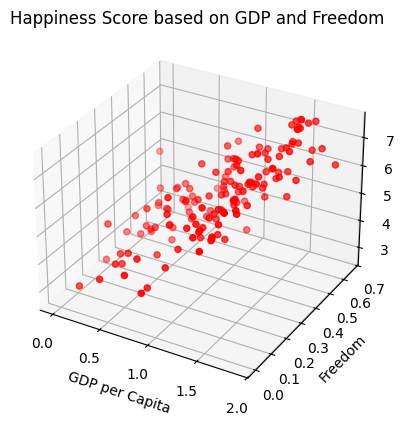

=== REZULTATE EVALUARE ===
MAE (Manual): 0.477335 | MAE (Tool): 0.477335
RMSE (Manual): 0.617016 | RMSE (Tool): 0.617016

=== VERIFICARE COEFICIENTI  ===
Intercept MyModel: 5.3517 | Intercept Sklearn: 5.3517
Coef MyModel: [0.7751482126042125, 0.3900198134191916] | Coef Sklearn: [0.77514821 0.39001981]


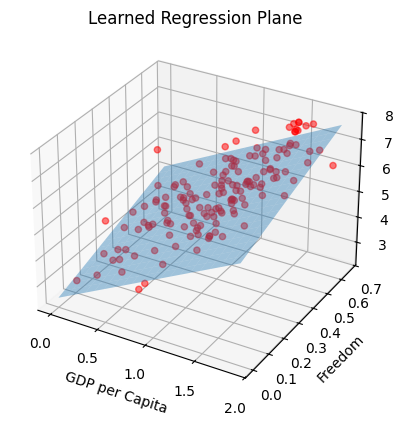

In [29]:
df = pd.read_csv("data/world-happiness-report-2017.csv")

features_cols = ['Economy..GDP.per.Capita.', 'Freedom']
target_col = 'Happiness.Score'

X = df[features_cols].values
Y = df[target_col].values

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X[:, 0], X[:, 1], Y, color = 'red')

ax.set_xlabel("GDP per Capita")
ax.set_ylabel("Freedom")
ax.set_zlabel("Happiness Score")

ax.set_title("Happiness Score based on GDP and Freedom")

plt.show()

X_scaled = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

indices = list(range(len(X_scaled)))
random.shuffle(indices)
split = int(0.8 * len(indices))

train_idx, test_idx = indices[:split], indices[split:]
X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
Y_train, Y_test = Y[train_idx], Y[test_idx]

my_model = MyBatchGradientDescent()
my_model.fit(X_train.tolist(), Y_train.tolist())
my_predictions = my_model.predict(X_test.tolist())

def manual_mae(real, pred):
    return sum(abs(r - p) for r, p in zip(real, pred)) / len(real)

def manual_rmse(real, pred):
    return math.sqrt(sum((r - p)**2 for r, p in zip(real, pred)) / len(real))

m_mae = manual_mae(Y_test, my_predictions)
m_rmse = manual_rmse(Y_test, my_predictions)

tool_mae = mean_absolute_error(Y_test, my_predictions)
tool_rmse = np.sqrt(mean_squared_error(Y_test, my_predictions))

print("=== REZULTATE EVALUARE ===")
print(f"MAE (Manual): {m_mae:.6f} | MAE (Tool): {tool_mae:.6f}")
print(f"RMSE (Manual): {m_rmse:.6f} | RMSE (Tool): {tool_rmse:.6f}")

print("\n=== VERIFICARE COEFICIENTI  ===")
sklearn_model = LinearRegression().fit(X_train, Y_train)
print(f"Intercept MyModel: {my_model.intercept_:.4f} | Intercept Sklearn: {sklearn_model.intercept_:.4f}")
print(f"Coef MyModel: {my_model.coef_} | Coef Sklearn: {sklearn_model.coef_}")

feature_names = ['GDP per Capita (scaled)', 'Freedom (scaled)']

gdp_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 20)
freedom_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 20)

gdp_grid, freedom_grid = np.meshgrid(gdp_range, freedom_range)

grid_points = np.c_[gdp_grid.ravel(), freedom_grid.ravel()]
grid_scaled = (grid_points - np.mean(X, axis=0)) / np.std(X, axis=0)

preds = my_model.predict(grid_scaled.tolist())
preds = np.array(preds).reshape(gdp_grid.shape)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X[:, 0], X[:, 1], Y, color='red', alpha=0.5)

ax.plot_surface(gdp_grid, freedom_grid, preds, alpha=0.4)

ax.set_xlabel("GDP per Capita")
ax.set_ylabel("Freedom")
ax.set_zlabel("Happiness Score")
ax.set_title("Learned Regression Plane")

plt.show()

Problema 2

In [52]:
class MyLogisticRegression1:
    def __init__(self):
        self.intercept_ = 0.0
        self.coef_ = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def fit(self, x, y, learningRate=0.1, noEpochs=1000):
        n_samples = len(x)
        n_features = len(x[0])
        self.weights = [0.0 for _ in range(n_features + 1)]

        for epoch in range(noEpochs):
            gradients = [0.0 for _ in range(n_features + 1)]
            for i in range(n_samples):
                z = self.weights[-1] + sum(self.weights[j] * x[i][j] for j in range(n_features))
                y_pred = self.sigmoid(z)
                error = y_pred - y[i]
                for j in range(n_features):
                    gradients[j] += error * x[i][j]
                gradients[-1] += error

            for j in range(len(self.weights)):
                self.weights[j] -= learningRate * (gradients[j] / n_samples)

        self.intercept_ = self.weights[-1]
        self.coef_ = self.weights[:-1]

    def predict_prob(self, x):
        return [self.sigmoid(self.intercept_ + sum(w * xi for w, xi in zip(self.coef_, row))) for row in x]

In [53]:
cols = ['ID', 'Diagnosis', 'Radius', 'Texture'] + [f'v{i}' for i in range(28)]
df = pd.read_csv("data/wdbc.data", names=cols, header=None)

X = df[['Radius', 'Texture']].values
Y = np.array([1 if d == 'M' else 0 for d in df['Diagnosis']])

mean, std = np.mean(X, axis=0), np.std(X, axis=0)
X_scaled = (X - mean) / std

my_clf = MyLogisticRegression1()
my_clf.fit(X_scaled.tolist(), Y.tolist())

tool_clf = LogisticRegression()
tool_clf.fit(X_scaled, Y)

new_sample = np.array([[18.0, 10.0]])
new_sample_scaled = (new_sample - mean) / std

prob_my = my_clf.predict_prob(new_sample_scaled.tolist())[0]
prob_tool = tool_clf.predict_proba(new_sample_scaled)[0][1]

print("=== COMPARATIE REZULTATE (Raza=18, Textura=10) ===")
print(f"Probabilitate (Manual): {prob_my:.4f} -> {'MALIGN' if prob_my >= 0.5 else 'BENIGN'}")
print(f"Probabilitate (Tool):   {prob_tool:.4f} -> {'MALIGN' if prob_tool >= 0.5 else 'BENIGN'}")

print("\n=== COMPARATIE PARAMETRI INVATATI ===")
print(f"Intercept: Manual {my_clf.intercept_:.4f} | Tool {tool_clf.intercept_[0]:.4f}")
print(f"Coeficienți: Manual {my_clf.coef_} | Tool {tool_clf.coef_[0]}")

=== COMPARATIE REZULTATE (Raza=18, Textura=10) ===
Probabilitate (Manual): 0.7429 -> MALIGN
Probabilitate (Tool):   0.7456 -> MALIGN

=== COMPARATIE PARAMETRI INVATATI ===
Intercept: Manual -0.6998 | Tool -0.6994
Coeficienți: Manual [np.float64(3.346142241143199), np.float64(0.8879189155336346)] | Tool [3.33642177 0.87670148]


Prolbema 3

In [41]:
import numpy as np

class MyLogisticRegression2:
    def __init__(self):
        self.intercept_ = 0.0
        self.coef_ = []
        self.loss_history = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def compute_loss(self, x, y):
        n = len(y)
        loss = 0
        for i in range(n):
            z = self.intercept_ + sum(w * xi for w, xi in zip(self.coef_, x[i]))
            p = self.sigmoid(z)
            p = np.clip(p, 1e-15, 1 - 1e-15)
            loss += -(y[i] * np.log(p) + (1 - y[i]) * np.log(1 - p))
        return loss / n

    def fit(self, x, y, learningRate=0.1, noEpochs=5000):
        n_samples = len(x)
        n_features = len(x[0])
        self.weights = [0.0 for _ in range(n_features + 1)]
        self.loss_history = []
        
        for epoch in range(noEpochs):
            gradients = [0.0 for _ in range(n_features + 1)]
            
            for i in range(n_samples):
                z = self.weights[-1] + sum(self.weights[j] * x[i][j] for j in range(n_features))
                y_pred = self.sigmoid(z)
                error = y_pred - y[i]
                
                for j in range(n_features):
                    gradients[j] += error * x[i][j]
                gradients[-1] += error
                
            for j in range(len(self.weights)):
                self.weights[j] -= learningRate * (gradients[j] / n_samples)
                
            self.intercept_ = self.weights[-1]
            self.coef_ = self.weights[:-1]
            
            if epoch % 100 == 0 or epoch == noEpochs - 1:
                current_loss = self.compute_loss(x, y)
                self.loss_history.append(current_loss)

    def predict_prob(self, x):
        z = self.intercept_ + sum(w * xi for w, xi in zip(self.coef_, x))
        return self.sigmoid(z)

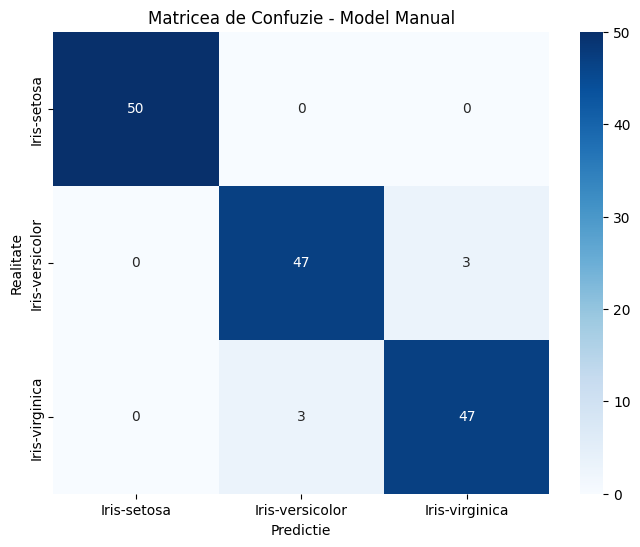

=== REZULTATE CLASIFICARE IRIS ===
Specie detectata (Manual): Iris-setosa
Probabilitati manuale: {'Iris-setosa': np.float64(0.9999815099794085), 'Iris-versicolor': np.float64(0.015069010906019774), 'Iris-virginica': np.float64(6.482773072196259e-13)}
------------------------------
Specie detectata (Tool):   Iris-setosa
Probabilitati tool:     {'Iris-setosa': np.float64(0.9999991357790304), 'Iris-versicolor': np.float64(8.642209694681178e-07), 'Iris-virginica': np.float64(4.818383273535361e-34)}


In [50]:
cols = ['sepal_len', 'sepal_wd', 'petal_len', 'petal_wd', 'class']
df = pd.read_csv("data/iris.data", names=cols)

X = df[['sepal_len', 'sepal_wd', 'petal_len', 'petal_wd']].values
Y_orig = df['class'].values
species = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']

mean, std = np.mean(X, axis=0), np.std(X, axis=0)
X_scaled = (X - mean) / std

models = {}
for s in species:
    binary_y = [1 if label == s else 0 for label in Y_orig]
    clf = MyLogisticRegression2()
    clf.fit(X_scaled.tolist(), binary_y, learningRate=0.5, noEpochs=3000)
    models[s] = clf

tool_clf = LogisticRegression(penalty=None)
tool_clf.fit(X_scaled, Y_orig)

final_preds = []
for sample in X_scaled:
    probs = {s: models[s].predict_prob(sample) for s in species}
    final_preds.append(max(probs, key=probs.get))

cm = confusion_matrix(Y_orig, final_preds, labels=species)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=species, yticklabels=species, cmap='Blues')
plt.xlabel('Predictie')
plt.ylabel('Realitate')
plt.title('Matricea de Confuzie - Model Manual')
plt.show()

new_iris = np.array([5.35, 3.85, 1.25, 0.4])
new_iris_scaled = (new_iris - mean) / std

manual_probs = {s: models[s].predict_prob(new_iris_scaled) for s in species}
manual_verdict = max(manual_probs, key=manual_probs.get)

tool_verdict = tool_clf.predict([new_iris_scaled])[0]
tool_probs = tool_clf.predict_proba([new_iris_scaled])[0]

print("=== REZULTATE CLASIFICARE IRIS ===")
print(f"Specie detectata (Manual): {manual_verdict}")
print(f"Probabilitati manuale: {manual_probs}")
print("-" * 30)
print(f"Specie detectata (Tool):   {tool_verdict}")
print(f"Probabilitati tool:     {dict(zip(species, tool_probs))}")

In [51]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score

new_iris = np.array([5.35, 3.85, 1.25, 0.4])
new_iris_scaled = (new_iris - mean) / std

kf = KFold(n_splits=5, shuffle=True, random_state=42)
manual_scores = []

print("=== INCEPUT VALIDARE INCRUCISATA ===")

for i, (train_index, test_index) in enumerate(kf.split(X_scaled)):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = Y_orig[train_index], Y_orig[test_index]
    
    fold_models = {}
    for s in species:
        binary_y_train = [1 if label == s else 0 for label in y_train]
        clf = MyLogisticRegression2()
        clf.fit(X_train.tolist(), binary_y_train, learningRate=0.5, noEpochs=1000)
        fold_models[s] = clf
    
    predictions = []
    for sample in X_test:
        probs = {s: fold_models[s].predict_prob(sample) for s in species}
        predictions.append(max(probs, key=probs.get))
    
    flower_probs = {s: fold_models[s].predict_prob(new_iris_scaled) for s in species}
    flower_verdict = max(flower_probs, key=flower_probs.get)
    
    acc = accuracy_score(y_test, predictions)
    manual_scores.append(acc)
    
    print(f"Fold {i+1}: Accuracy = {acc:.4f} | Predicție floare test: {flower_verdict}")

print("-" * 40)
print(f"Manual CV Accuracy per fold: {manual_scores}")
print(f"Manual Mean Accuracy: {np.mean(manual_scores):.4f}")

final_probs = {s: fold_models[s].predict_prob(new_iris_scaled) for s in species}
print(f"\nVerdict final pentru floarea [5.35, 3.85, 1.25, 0.4]: {max(final_probs, key=final_probs.get)}")
print(f"Probabilități detaliate: {final_probs}")

=== ÎNCEPUT VALIDARE ÎNCRUCIȘATĂ ===
Fold 1: Accuracy = 1.0000 | Predicție floare test: Iris-setosa
Fold 2: Accuracy = 0.9333 | Predicție floare test: Iris-setosa
Fold 3: Accuracy = 0.9333 | Predicție floare test: Iris-setosa
Fold 4: Accuracy = 0.9000 | Predicție floare test: Iris-setosa
Fold 5: Accuracy = 0.9667 | Predicție floare test: Iris-setosa
----------------------------------------
Manual CV Accuracy per fold: [1.0, 0.9333333333333333, 0.9333333333333333, 0.9, 0.9666666666666667]
Manual Mean Accuracy: 0.9467

Verdict final pentru floarea [5.35, 3.85, 1.25, 0.4]: Iris-setosa
Probabilități detaliate: {'Iris-setosa': np.float64(0.999891091790783), 'Iris-versicolor': np.float64(0.0159926491004232), 'Iris-virginica': np.float64(4.722113246069349e-09)}


In [48]:
probabilitate_setosa = models['Iris-setosa'].predict_prob(new_iris_scaled)

praguri = [0.2, 0.5, 0.8, 1]
for p in praguri:
    verdict = "Setosa" if probabilitate_setosa >= p else "Nu e Setosa"
    print(f"La pragul {p}, verdictul este: {verdict}")

La pragul 0.2, verdictul este: Setosa
La pragul 0.5, verdictul este: Setosa
La pragul 0.8, verdictul este: Setosa
La pragul 1, verdictul este: Nu e Setosa


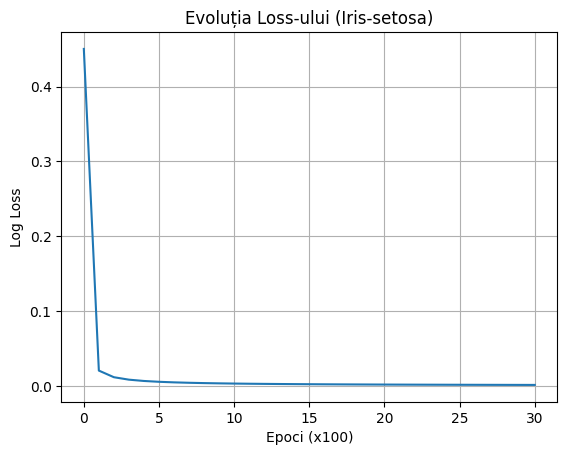

In [49]:
plt.plot(models['Iris-setosa'].loss_history)
plt.title('Evoluția Loss-ului (Iris-setosa)')
plt.xlabel('Epoci (x100)')
plt.ylabel('Log Loss')
plt.grid(True)
plt.show()